In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss, accuracy_score

import warnings
warnings.filterwarnings('ignore')

from copy import deepcopy

## Generación de datos

In [3]:
# Diagonales

def diagonales(n, d, C):
  mean0 = np.full(d,-1)
  mean1 = np.full(d,1)
    
  desviacion_std = C * np.sqrt(d)
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Paralelas

def paralelas(n, d, C):
  mean0 = np.zeros(d)
  mean1 = np.zeros(d)
  mean0[0] = 1
  mean1[0] = -1

  desviacion_std = C
  covarianza = np.diag(np.full(d,desviacion_std)**2)
    
  input0 = np.random.multivariate_normal(mean0, covarianza, n//2)
  input1 = np.random.multivariate_normal(mean1, covarianza, n//2)
    
  output0 = np.full(n//2, 0)  
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0, output1]).tolist()


# Espirales

def toCartesianP(r, theta):
  x = r * np.cos(theta)
  y = r * np.sin(theta)
  return (x, y)

def toCartesianA(rs, thetas):
  a = [(r * np.cos(theta), r * np.sin(theta)) for r, theta in zip(rs, thetas)]
  return a

def espirales(n):
  r0s = np.sqrt(np.random.uniform(0, 1, n//2))  
  a0s = np.random.uniform(0, 1, n//2)
  theta0s = [np.pi*(4*r-a) for r,a in zip(r0s,a0s)]

  r1s = np.sqrt(np.random.uniform(0, 1, n//2))
  a1s = np.random.uniform(-1, 0, n//2)
  theta1s = [np.pi*(4*r-a) for r,a in zip(r1s,a1s)]

  input0 = toCartesianA(r0s,theta0s)
  input1 = toCartesianA(r1s,theta1s)

  output0 = np.full(n//2, 0)
  output1 = np.full(n//2, 1)

  return np.concatenate([input0,input1]).tolist(), np.concatenate([output0,output1]).tolist()

## Definimos nuestras redes

In [4]:
# Defino MLP para regresión
def Regressor():
    return MLPRegressor(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa,nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

# Defino MLP para clasificación
def Classifier():
    return MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

## Funcion de entrenamiento

In [7]:
def entrenar_red(red: MLPClassifier | MLPRegressor,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
  
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red

    error_function = zero_one_loss if isinstance(red, MLPClassifier) else mean_squared_error
    
    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      red.fit(X_train, y_train)

      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(error_function(y_train, y_pred_train))
      
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = error_function(y_val, y_pred_val)
      error_val.append(cur_val)
      
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)

    return best_red, error_train, error_val, error_test

## Ejercicio 1

Resolvemos el problema de las espirales anidadas, utilizando redes neuronales variando el numero de capas intermedias.

In [ ]:
eta = 0.1
alfa = 0.9
N2s = [2, 10, 20, 40]
sub_epocas = 20
super_epocas = 1000

# Uso el mismo conjunto de entrenamiento y de test para todas las N2
# Asi se puede comparar el rendimiento de los modelos
X_data, Y_data = espirales(600)
X_test, Y_test = espirales(2000)

X_train,X_val,Y_train,Y_val = skl.model_selection.train_test_split(X_data, Y_data, test_size=0.2)
    

# Un diccionario con un resultado por cada N2
df = {}

# Guardo los mejores modelos de cada N2
best_fits: dict[int, MLPClassifier] = {}

for N2 in N2s:
    cla = Classifier()

    best_fit, train_error, val_error, test_error = entrenar_red(cla, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    
    Y_ans = best_fit.predict(X_test)

    best_fits[N2] = best_fit
    df[N2] = {"train_error": train_error, "val_error": val_error, "test_error": test_error}

df = pd.DataFrame.from_dict(df)

Ahora graficamos las predicciones obtenidas

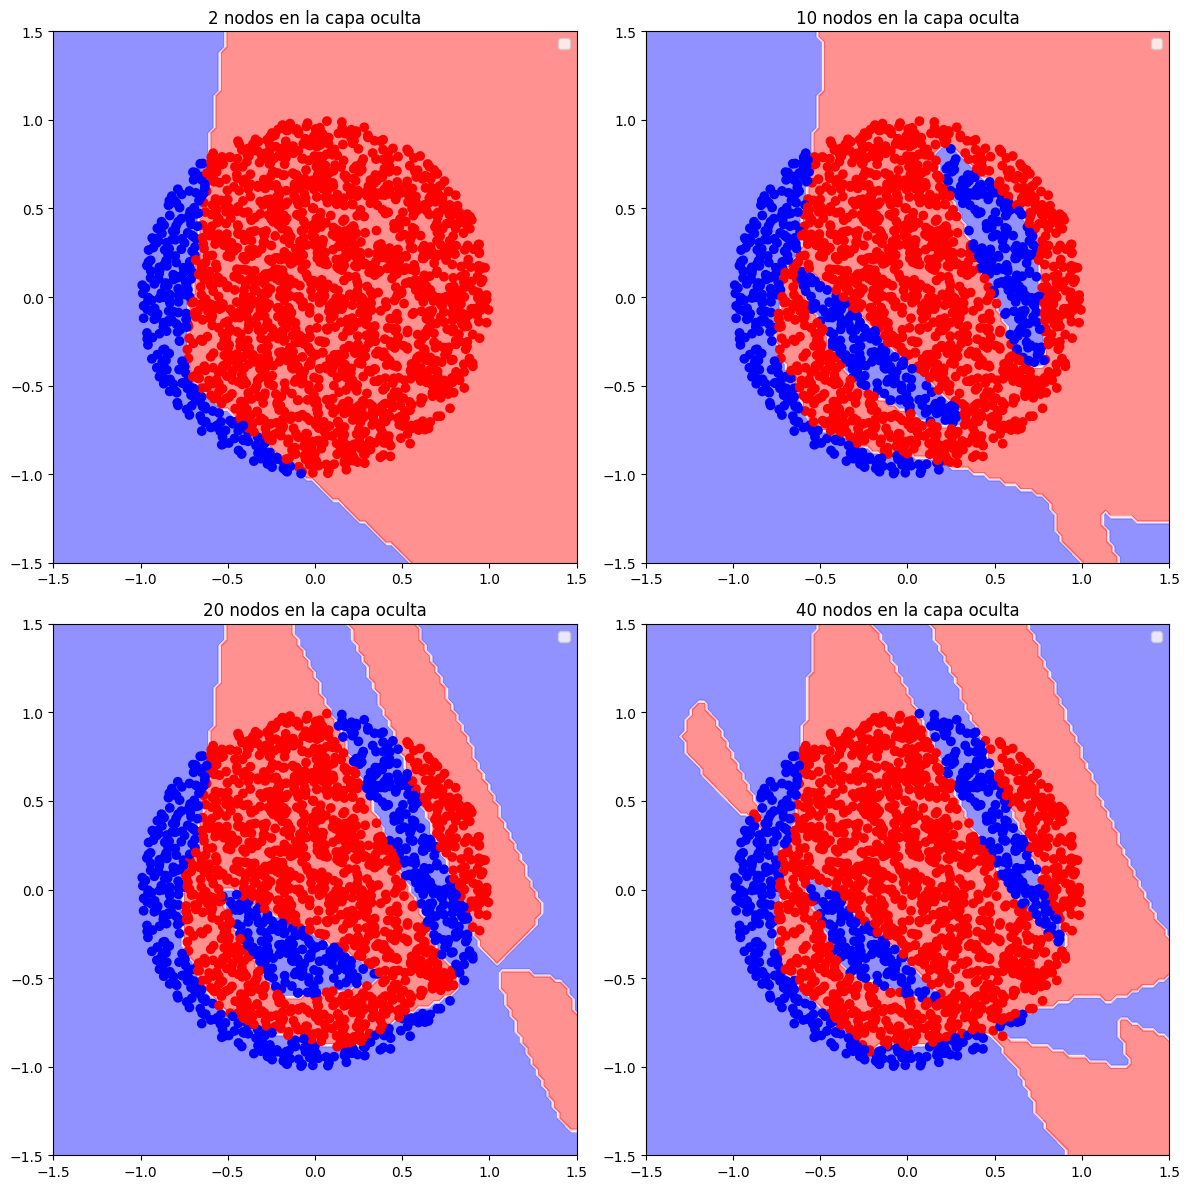

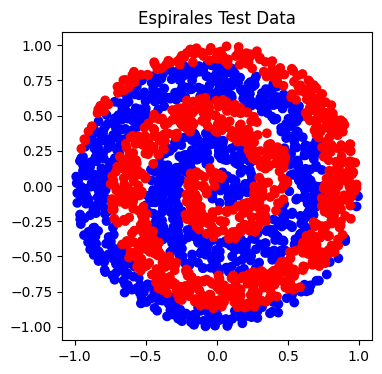

In [ ]:
def plotEspiral(dd):
    N2s = dd.keys()
    fig, axs = plt.subplots(2, 2, figsize=(12, 12))

    # Puntos de una grilla, para graficar los contornos que diferencian las clases
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))

    axs = [ax for fila in axs for ax in fila]
    
    for N2, ax in zip(N2s, axs):
        # Clasifico los puntos de la espiral
        X = X_test
        Y = best_fits[N2].predict(X)

        # Clasifico los puntos de la grilla
        Z = best_fits[N2].predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        
        # Grafico los contornos
        ax.contourf(xx, yy, Z, alpha=0.5, cmap="bwr")

        ax.scatter([x[0] for x in X], [x[1] for x in X], c=Y, cmap="bwr")
        ax.set_title("{} nodos en la capa oculta".format(N2))
        ax.legend()
    plt.tight_layout()
    plt.show()

plotEspiral(df)


plt.figure(figsize=(4, 4))
plt.scatter([x[0] for x in X_test], [x[1] for x in X_test], c=Y_test, cmap="bwr")
plt.title("Espirales Test Data")
plt.show()

Al aumentar la cantidad de nodos en la capa oculta lo que se obtiene es una mejora a la hora de generar la espirales. Esto se debe a que en cada caso se generan mas hiperplanos (desde nuestra perpectiva serian rectas mas que hiperplanos), por lo que se puede de limitar de mejora manera las 2 clases de puntos.

* Una primera observación importante es que los resultados no son tan buenos a los obtenidos  al utilizar arboles, debido a que en este caso los puntos no son linealmente separable, haciendo que el resultado no sea tan preciso (a pesar de que el descenso de gradiente estocástico da el resultado mas preciso cuando no son linealmente separables).

* La segunda observación es que se necesitarían infinitos hiperplanos para poder aproximar de forma efectiva las espirales.

## Ejercicio 2

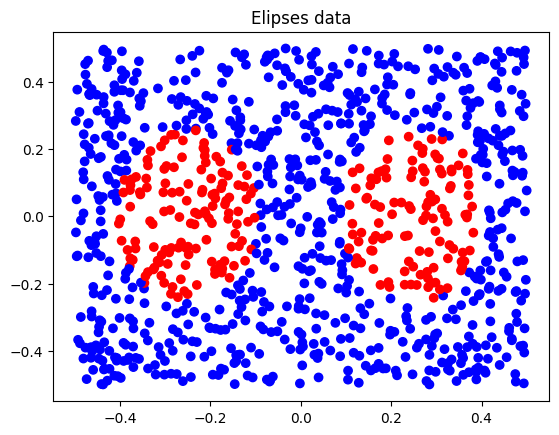

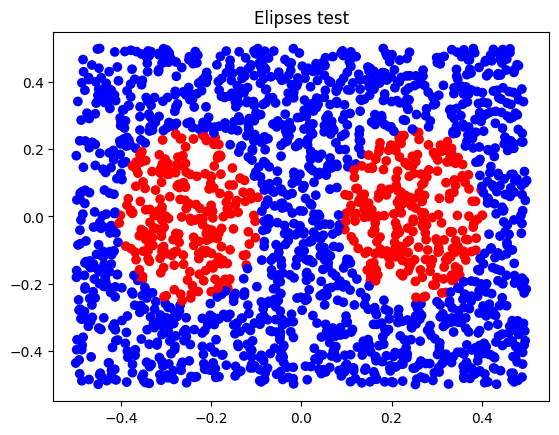

In [19]:
def cargar_csv(path, xcols=2):
    df = pd.read_csv(path, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

def plot_elipses(data):
    p = data[0]
    c = data[1]

    plt.scatter(p[0], p[1], c=c, cmap="bwr")
    plt.show()

data = cargar_csv("dos_elipses.data")

plt.title("Elipses data")
plot_elipses(data)

test = cargar_csv("dos_elipses.test")
plt.title("Elipses test")
plot_elipses(test)

Entreno los perceptrones

In [10]:
N2 = 6
super_epocas = 300
sub_epocas = 50

TRAINS = 10

# Probar diferentes momentos y learning rates

# Elegir un momento
#alfa = 0.5

# Elegir un learning rate
#eta = 0.1

#alfas = [0.2]
#etas = [0.3]

# Probamos una combinacion de valores de alfa y eta
alfa_etas = [(0, 0.1), (0, 0.01), (0, 0.001), (0.5, 0.1), (0.5, 0.01), (0.5, 0.001),
             (0.9, 0.1), (0.9, 0.01), (0.9, 0.001), (0.2, 0.3), (0.02, 0.3), (0.002, 0.3)]

# Recolectamos los datos de entrenamiento para cada uno

df = {}

for alfa,eta in alfa_etas:
    best_train_error = []
    best_val_error = []
    best_test_error = []
    train_errors = []
    val_errors = []
    test_errors = []


    # Todos los entrenamientos deben ser iguales, asi que los conjuntos van a
    # a ser los mismos

    # Elegir 500 valores del conjunto de data
    X_data,_,Y_data,_ = skl.model_selection.train_test_split(data[0].values.tolist(), data[1].values.tolist(), train_size=500)
    
    # Apartar 100 valores para validación
    X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(X_data,Y_data, train_size=400)
    
    # Elegir 2000 valores del conjunto de test
    _,X_test,_,Y_test = skl.model_selection.train_test_split(test[0].values.tolist(), test[1].values.tolist())
    for i in range(TRAINS):
        cla = Classifier()

        best_fit, train_error, val_error, test_error = entrenar_red(cla,X_train,Y_train,X_val,Y_val,X_test,Y_test)
    
        y_best_pred_train = best_fit.predict(X_train)
        y_best_pred_val = best_fit.predict(X_val)
        y_best_pred_test = best_fit.predict(X_test)

        best_train_error.append(zero_one_loss(Y_train, y_best_pred_train))
        best_val_error.append(zero_one_loss(Y_val, y_best_pred_val))
        best_test_error.append(zero_one_loss(Y_test, y_best_pred_test))
        train_errors.append(train_error)
        val_errors.append(val_error)
        test_errors.append(test_error)

    print("Alfa:", alfa, "Eta:", eta)
    print("Error de test:", np.mean(test_error)*100)
    print("Desviación estándar:", np.std(test_error)*100)
    print("\n")

    df[(alfa,eta)] = {
        "train_error": train_errors,
        "val_error": val_errors,
        "test_error": test_errors,
        "best_train_error": best_train_error,
        "best_val_error": best_val_error,
        "best_test_error": best_test_error
    }
    
df = pd.DataFrame.from_dict(df)
display(df)

Alfa: 0 Eta: 0.1
Error de test: 11.275333333333336
Desviación estándar: 8.475222212753806


Alfa: 0 Eta: 0.01
Error de test: 23.400000000000002
Desviación estándar: 2.7755575615628914e-15


Alfa: 0 Eta: 0.001
Error de test: 23.400000000000002
Desviación estándar: 2.7755575615628914e-15


Alfa: 0.5 Eta: 0.1
Error de test: 7.276000000000001
Desviación estándar: 5.277078484666807


Alfa: 0.5 Eta: 0.01
Error de test: 24.599999999999994
Desviación estándar: 5.551115123125783e-15


Alfa: 0.5 Eta: 0.001
Error de test: 22.799999999999997
Desviación estándar: 0.0


Alfa: 0.9 Eta: 0.1
Error de test: 7.232000000000002
Desviación estándar: 4.656670054878269


Alfa: 0.9 Eta: 0.01
Error de test: 16.131999999999998
Desviación estándar: 6.3695245243790914


Alfa: 0.9 Eta: 0.001
Error de test: 23.748666666666672
Desviación estándar: 0.4025314342452721


Alfa: 0.2 Eta: 0.3
Error de test: 14.81
Desviación estándar: 2.5369338448870375


Alfa: 0.02 Eta: 0.3
Error de test: 17.416666666666668
Desviación está

0.000  \
                                                              0.100   
train_error       [[0.23250000000000004, 0.23250000000000004, 0....   
val_error         [[0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0.24, 0....   
test_error        [[0.244, 0.244, 0.244, 0.244, 0.244, 0.244, 0....   
best_train_error  [0.1975, 0.1725, 0.07250000000000001, 0.007499...   
best_val_error    [0.09999999999999998, 0.07999999999999996, 0.0...   
best_test_error   [0.19199999999999995, 0.17200000000000004, 0.0...   

                                                                     \
                                                              0.010   
train_error       [[0.255, 0.255, 0.255, 0.255, 0.255, 0.255, 0....   
val_error         [[0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0....   
test_error        [[0.23399999999999999, 0.23399999999999999, 0....   
best_train_error  [0.255, 0.255, 0.255, 0.255, 0.255, 0.255, 0.2...   
best_val_error    [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.2...   
best_test_error   [0.23399999999999999, 0.23399999999999999, 0.2...   

                                                                     \
                                                              0.001   
train_error       [[0.245, 0.245, 0.245, 0.245, 0.245, 0.245, 0....   
val_error         [[0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0....   
test_error        [[0.23399999999999999, 0.23399999999999999, 0....   
best_train_error  [0.245, 0.245, 0.245, 0.245, 0.245, 0.245, 0.2...   
best_val_error    [0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0.26, 0.2...   
best_test_error   [0.23399999999999999, 0.23399999999999999, 0.2...   

                                                              0.500  \
                                                              0.100   
train_error       [[0.17500000000000004, 0.16500000000000004, 0....   
val_error         [[0.19999999999999996, 0.19999999999999996, 0....   
test_error        [[0.16200000000000003, 0.132, 0.14400000000000...   
best_train_error  [0.12250000000000005, 0.16249999999999998, 0.0...   
best_val_error    [0.13, 0.17000000000000004, 0.0899999999999999...   
best_test_error   [0.11399999999999999, 0.14, 0.0639999999999999...   

                                                                     \
                                                              0.010   
train_error       [[0.255, 0.255, 0.255, 0.255, 0.255, 0.255, 0....   
val_error         [[0.18999999999999995, 0.18999999999999995, 0....   
test_error        [[0.246, 0.246, 0.246, 0.246, 0.246, 0.246, 0....   
best_train_error  [0.255, 0.255, 0.255, 0.255, 0.255, 0.255, 0.2...   
best_val_error    [0.18999999999999995, 0.18999999999999995, 0.1...   
best_test_error   [0.246, 0.246, 0.246, 0.246, 0.246, 0.246, 0.2...   

                                                                     \
                                                              0.001   
train_error       [[0.26249999999999996, 0.26249999999999996, 0....   
val_error         [[0.19999999999999996, 0.19999999999999996, 0....   
test_error        [[0.22799999999999998, 0.22799999999999998, 0....   
best_train_error  [0.26249999999999996, 0.26249999999999996, 0.2...   
best_val_error    [0.19999999999999996, 0.19999999999999996, 0.1...   
best_test_error   [0.22799999999999998, 0.22799999999999998, 0.2...   

                                                              0.900  \
                                                              0.100   
train_error       [[0.26, 0.26, 0.20750000000000002, 0.26, 0.217...   
val_error         [[0.21999999999999997, 0.21999999999999997, 0....   
test_error        [[0.242, 0.242, 0.18799999999999994, 0.242, 0....   
best_train_error  [0.13749999999999996, 0.13, 0.0300000000000000...   
best_val_error    [0.12, 0.12, 0.010000000000000009, 0.010000000...   
best_test_error   [0.10999999999999999, 0.124, 0.040000000000000...   

                                                                     \
        

## Ejercicio 3

In [11]:
column_names = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
data = pd.read_csv('ikeda.data', delim_whitespace=True, header=None, names=column_names)
test = pd.read_csv('ikeda.test', delim_whitespace=True, header=None, names=column_names)

display(data)
display(test)

TRAINS = 10

eta = 0.01
alfa = 0.9
super_epocas = 400
sub_epocas = 50
N2 = 30

PORCENTAJE_TRAIN = [0.95, 0.75, 0.5]

df = {
    0.95: {},
    0.75: {},
    0.5: {}
}

# Elegir 2000 valores del conjunto de test


for p in PORCENTAJE_TRAIN:
    _, X_test, _, Y_test = skl.model_selection.train_test_split(test.iloc[:, :-1].values.tolist(), test.iloc[:, -1].values.tolist(),test_size=2000)
    etrain = []
    eeval = []
    etest = []

    # Elegir valores del conjunto de data
    X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(data.iloc[:, :-1].values.tolist(), data.iloc[:, -1].values.tolist(), train_size=p)

    for i in range(TRAINS):
        reg = Regressor()

        best_fit, *_ = entrenar_red(reg, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    
        etrain.append(mean_squared_error(Y_train, best_fit.predict(X_train)))
        eeval.append(mean_squared_error(Y_val, best_fit.predict(X_val)))
        etest.append(mean_squared_error(Y_test, best_fit.predict(X_test)))

    df[p] = {
        "train_error": etrain,
        "val_error": eeval,
        "test_error": etest
    }

df = pd.DataFrame.from_dict(df)

C:\Users\Ramiro\AppData\Local\Temp\ipykernel_13720\1680719314.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv('ikeda.data', delim_whitespace=True, header=None, names=column_names)
C:\Users\Ramiro\AppData\Local\Temp\ipykernel_13720\1680719314.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  test = pd.read_csv('ikeda.test', delim_whitespace=True, header=None, names=column_names)


,x1,x2,x3,x4,x5,x6
0,0.907938,0.580088,0.165603,0.701732,0.354170,0.976418
1,0.580088,0.165603,0.701732,0.354170,0.976418,0.464438
2,0.165603,0.701732,0.354170,0.976418,0.464438,0.462873
3,0.701732,0.354170,0.976418,0.464438,0.462873,0.447031
4,0.354170,0.976418,0.464438,0.462873,0.447031,1.023614
...,...,...,...,...,...,...
95,0.590963,0.408041,0.921964,0.443131,0.614752,0.556577
96,0.408041,0.921964,0.443131,0.614752,0.556577,0.437420
97,0.921964,0.443131,0.614752,0.556577,0.437420,0.419920
98,0.443131,0.614752,0.556577,0.437420,0.419920,1.114815


,x1,x2,x3,x4,x5,x6
0,0.498048,0.655449,0.342761,1.138024,0.678734,-0.081692
1,0.655449,0.342761,1.138024,0.678734,-0.081692,1.052985
2,0.342761,1.138024,0.678734,-0.081692,1.052985,0.204229
3,1.138024,0.678734,-0.081692,1.052985,0.204229,1.299434
4,0.678734,-0.081692,1.052985,0.204229,1.299434,1.222963
...,...,...,...,...,...,...
4795,0.849172,0.382464,0.975345,0.951475,0.031079,1.018942
4796,0.382464,0.975345,0.951475,0.031079,1.018942,1.296063
4797,0.975345,0.951475,0.031079,1.018942,1.296063,0.579384
4798,0.951475,0.031079,1.018942,1.296063,0.579384,-0.150451


c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Ramiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the opti

,0.95,0.75,0.50
train_error,"[0.05057651986586206, 0.04089186110479864, 0.0...","[0.048990027332838, 0.058299568957089855, 0.05...","[0.09907391998130702, 0.08823538897167793, 0.1..."
val_error,"[0.011682067876025612, 0.012036120613134938, 0...","[0.10298328768737137, 0.09334438208775081, 0.0...","[0.15055994835774322, 0.13802690194700817, 0.1..."
test_error,"[0.0823504116725955, 0.08020366301178428, 0.09...","[0.07534177825092347, 0.08021310176806373, 0.0...","[0.13807838107146506, 0.12299405411565756, 0.1..."


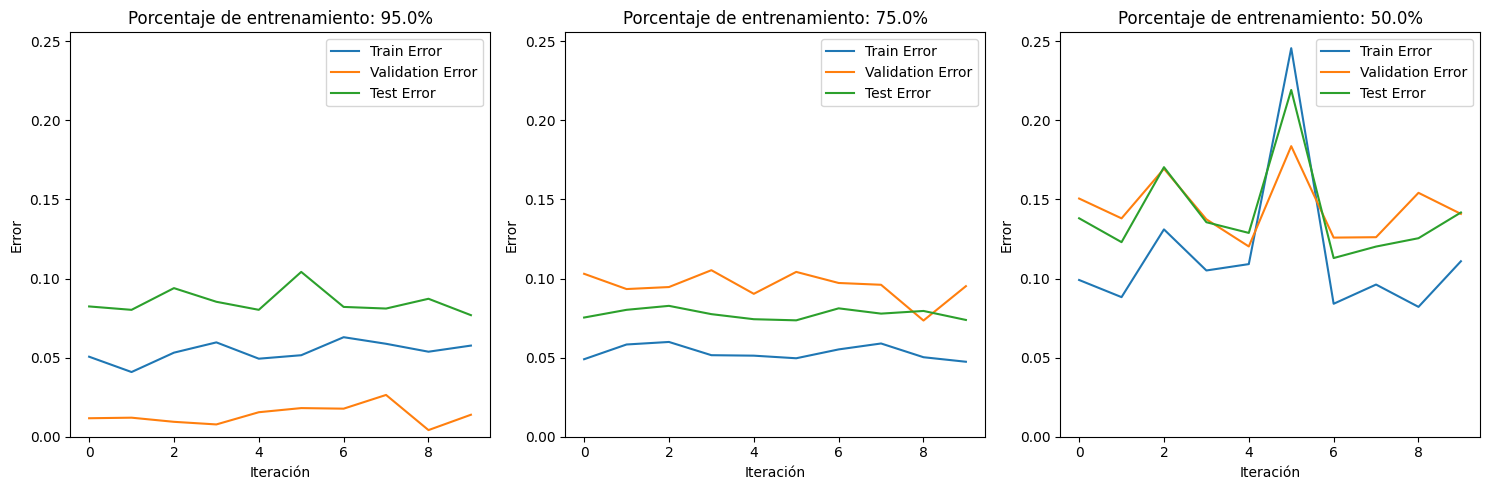

In [12]:
display(df)

# Para cada porcentaje mostrar la distribucion de los errores
def plot_ikeda(df):
    # Graficar la evolucion del promedio de errores, respecto al porcentaje de entrenamiento
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for i, p in enumerate(df.keys()):
        axs[i].plot(df[p]["train_error"], label="Train Error")
        axs[i].plot(df[p]["val_error"], label="Validation Error")
        axs[i].plot(df[p]["test_error"], label="Test Error")
        axs[i].set_title(f"Porcentaje de entrenamiento: {p*100}%")
        axs[i].set_xlabel("Iteración")
        axs[i].set_ylabel("Error")
        axs[i].legend()

    # Igualar el eje de las y para cada grafica
    y_max = df[0.95]["train_error"][0]
    for p in df.keys():
        y_max = max(y_max, max(df[p]["train_error"]), max(df[p]["val_error"]), max(df[p]["test_error"]))
    for ax in axs:
        ax.set_ylim(0, y_max+0.01)

    plt.tight_layout()
    plt.show()
plot_ikeda(df)

Como primera observación se tiene que a medida que aumenta el conjunto de validación el error va aumentando. Esto se debe a que al haber mas valores posibles es mas probables que se seleccionen datos que no sea "malos" (es decir erróneos):

La explicación que le damos a lo dicho anteriormente es la siguiente, un conjunto de validación grande hace que sea mas fácil que la "best_red" sea reemplazada durante el entrenamiento (mas fácil encontrar un menor error en una muestra grande). De manera análoga, si el conjunto de validación es pequeño se hace mas complicado encontrar un menor error durante el entrenamiento, haciendo que la "best_red" no sea propensa a cambiar.

Los otros 2 conjuntos tienden a mantener los error dentro del mismo rango de valores en los tres casos. El unció que llega a variar un poco es el de test. Esto se puede deber a que se reduce la muestra, haciendo mas difícil la clasificación.

Un ultima observación es que en el caso 75%-25% se tiene que los tres errores tienden a mantenerse constante a lo largo de la iteraciones, esto se puede deber a que la separación del conjunto de validación y el de train es justa (equilibrada).


## Ejercicio 4

Repetimos el ejercicio anterior utilizando weight-decay. Utilizamos el dataset de Sunspots y buscamos un valor de gamma adecuado.

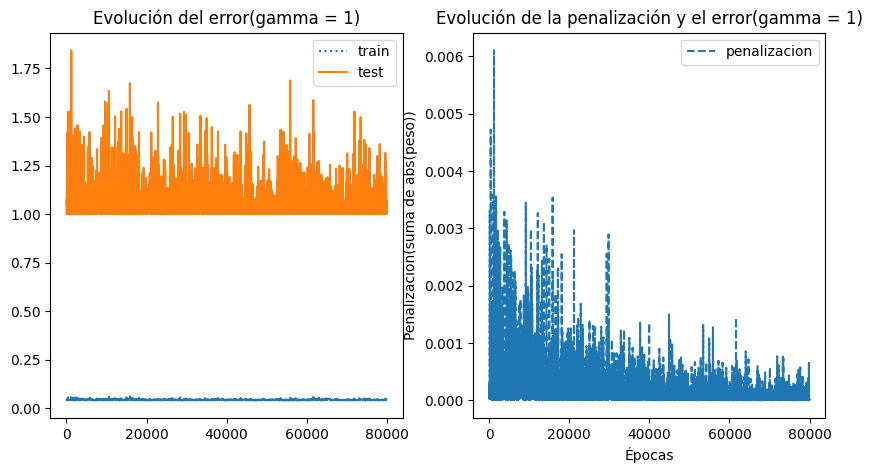

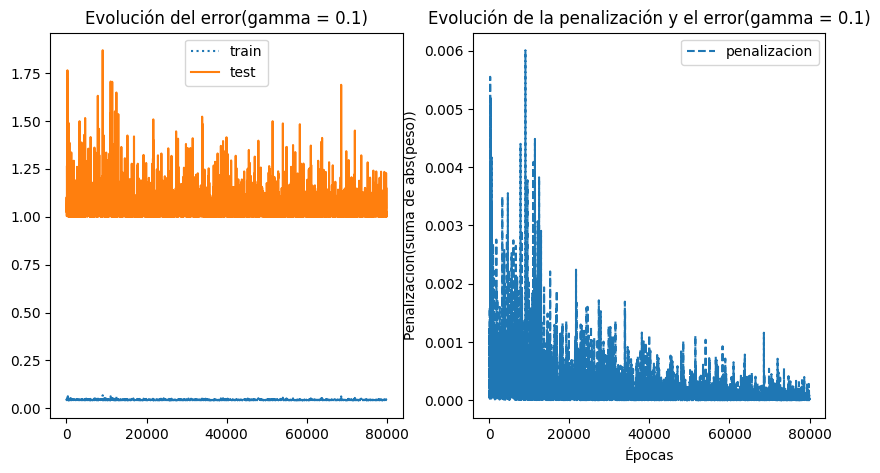

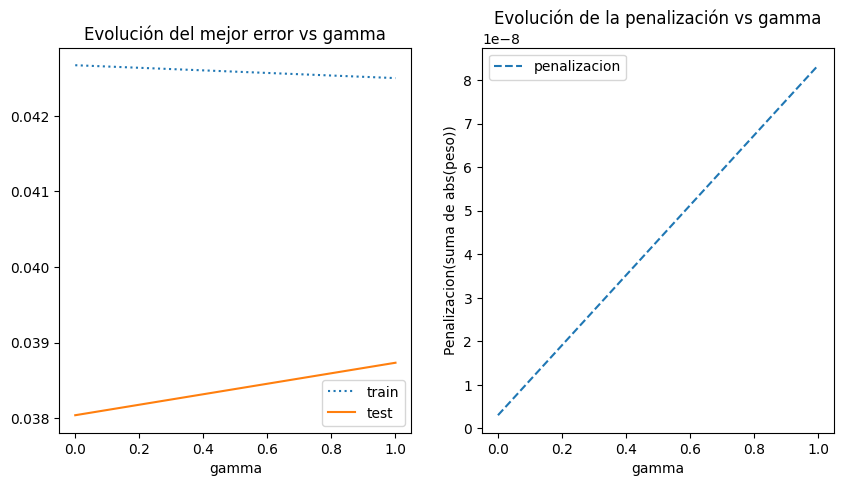

In [ ]:
def calcular_penalizacion(coeff):
   return sum(np.square(w).sum() for w in coeff)

def entrenar_red(red: MLPClassifier | MLPRegressor,
                 X_train, y_train,
                 X_test,  y_test):
    
    error_train = []
    penalizacion = []
    error_test = []
    best_val = 1.0
    best_red = red
    

    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      red.fit(X_train, y_train)

      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(mean_squared_error(y_train, y_pred_train))
      
      # error de validacion
      error_test.append(1 - red.score(X_test, y_test))
      suma_pesos = calcular_penalizacion(red.coefs_)
      penalizacion.append(suma_pesos)
      
      if best_val > suma_pesos:
        best_val = suma_pesos
        best_red = deepcopy(red)
    return best_red, error_train, penalizacion, error_test

df = pd.read_csv("ssp.data", header=None)

X_train = df.iloc[:, :-1].values.tolist()
Y_train = df.iloc[:, -1].values.tolist()

df_test = pd.read_csv("ssp.test", header=None)

X_test = df_test.iloc[:, :-1].values.tolist()
Y_test = df_test.iloc[:, -1].values.tolist()

eta = 0.05
alfa = 0.3
super_epocas = 4000
sub_epocas = 20
N2 = 6

total_train_error = []
total_penalizacion = []
total_test_error = []

for e in range(7):
  fig, ax = plt.subplots(1, 2, figsize = (10, 5))
  gamma = 10**(-e)
  
  regr = MLPRegressor(hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', 
    alpha=gamma, batch_size=1, learning_rate='constant', 
    learning_rate_init=eta,momentum=alfa,nesterovs_momentum=False,tol=0.0,warm_start=True,max_iter=sub_epocas)
    
  best_fit, train_error, penalizacion, test_error = entrenar_red(regr, X_train, Y_train, X_test, Y_test)

  ans_train = best_fit.predict(X_train)
  ans_test = best_fit.predict(X_test)

  total_train_error.append(mean_squared_error(Y_train, ans_train))
  total_test_error.append(mean_squared_error(Y_test, ans_test))
  total_penalizacion.append(calcular_penalizacion(best_fit.coefs_))

  rango = np.array(range(super_epocas)) * sub_epocas
  ax[0].plot(rango, train_error, label="train", linestyle=":")
  ax[0].plot(rango, test_error, label="test", linestyle="-")
  ax[0].set_title("Evolución del error(gamma = {})".format(gamma))
  ax[0].legend()


  ax[1].plot(rango, penalizacion, label="penalizacion", linestyle="--")
  ax[1].set_xlabel("Épocas")
  ax[1].set_ylabel("Penalizacion(suma de abs(peso))")
  ax[1].legend()
  ax[1].set_title("Evolución de la penalización y el error(gamma = {})".format(gamma))

rango = range(7)
fig, ax = plt.subplots(1, 2, figsize = (10, 5))
ax[0].plot(rango, total_train_error, label="train", linestyle=":")
ax[0].plot(rango, total_test_error, label="test", linestyle="-")
ax[0].set_xlabel("gamma")
ax[0].set_title("Evolución del mejor error vs gamma".format(gamma))
ax[0].legend()

ax[1].plot(rango, total_penalizacion, label="penalizacion", linestyle="--")
ax[1].set_title("Evolución de la penalización vs gamma")
ax[1].set_xlabel("gamma")
ax[1].set_ylabel("Penalizacion(suma de abs(peso))")
ax[1].legend()

En base a las gráficas podemos observar que a medida que el gama va aumentando la penalización también va aumentando, pero en valores grandes este esta estable. Como ejemplo tenemos que en (10^-3) penalización varia en menos de 0.05, pero con (10^-6) el error varia en alrededor de 10.

De la ultima gráfica se puede ver que al para gamas demasiados chico podría empezar a ver "overfitting" (error del train tiende a crecer mas que el de test). Esto es porque al mantener gamas muy pequeños los pesos no tienden a reducirse mucho, produciendo el overffiting. Ademas, el mejor valor de gamma es el que se encuentra alrededor del -3, ya que los errores del train y test son prácticamente iguales.

La ultima observación es que a medida que el gamma disminuye los errores también disminuyen, esto se puede deber a que


## Ejercicio 5

In [12]:
# Hiperparametros
N2 = 6
eta = 0.1
alfa = 0.9
super_epocas = 300
sub_epocas = 50

# Uso la funcion de entrenar red que usa el conjunto de validacion
def entrenar_red(red: MLPClassifier | MLPRegressor,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
  
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red

    error_function = zero_one_loss if isinstance(red, MLPClassifier) else mean_squared_error
    
    evaluaciones = super_epocas

    for epoch in range(evaluaciones):
      red.fit(X_train, y_train)

      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(error_function(y_train, y_pred_train))
      
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = error_function(y_val, y_pred_val)
      error_val.append(cur_val)
      
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)

    return best_red, error_train, error_val, error_test

def getDfFromProblem(gen):
    ds = [2, 4, 8, 16, 32]
    
    # Cantidad de entrenamientos
    TRAINS = 20

    df = {}

    for d in ds:
        X_test, Y_test = gen(10000, d, 0.78)

        cla = Classifier()

        total_train_error = []
        total_val_error = []
        total_test_error = []

        for i in range(TRAINS):
            X_data, Y_data = gen(250, d, 0.78)
            X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(X_data, Y_data, test_size=0.2) 
            best_fit, *_ = entrenar_red(cla, X_train, Y_train, X_val, Y_val, X_test, Y_test)

            ans_train = best_fit.predict(X_train)
            ans_val = best_fit.predict(X_val)
            ans_test = best_fit.predict(X_test)

            total_train_error.append(zero_one_loss(Y_train, ans_train))
            total_val_error.append(zero_one_loss(Y_val, ans_val))
            total_test_error.append(zero_one_loss(Y_test, ans_test))

        df[d] = {'train_error': total_train_error,
                 'val_error': total_val_error,
                 'test_error': total_test_error}

    return pd.DataFrame.from_dict(df)



df_diagonales = getDfFromProblem(diagonales)
print("Estos son los datos de las diagonales")
display(df_diagonales)
df_paralelas = getDfFromProblem(paralelas)
print("Estos son los datos de las paralelas")
display(df_paralelas)

Estos son los datos de las diagonales


,2,4,8,16,32
train_error,"[0.050000000000000044, 0.10499999999999998, 0....","[0.13, 0.13, 0.18000000000000005, 0.12, 0.0999...","[0.040000000000000036, 0.08499999999999996, 0....","[0.06499999999999995, 0.06499999999999995, 0.1...","[0.135, 0.08999999999999997, 0.104999999999999..."
val_error,"[0.14, 0.12, 0.06000000000000005, 0.12, 0.0200...","[0.14, 0.14, 0.040000000000000036, 0.099999999...","[0.07999999999999996, 0.09999999999999998, 0.0...","[0.09999999999999998, 0.06000000000000005, 0.0...","[0.14, 0.06000000000000005, 0.0799999999999999..."
test_error,"[0.10099999999999998, 0.12150000000000005, 0.1...","[0.11850000000000005, 0.1523, 0.17589999999999...","[0.11040000000000005, 0.12019999999999997, 0.1...","[0.13660000000000005, 0.12129999999999996, 0.1...","[0.18259999999999998, 0.16910000000000003, 0.1..."


Estos son los datos de las paralelas


,2,4,8,16,32
train_error,"[0.08499999999999996, 0.10999999999999999, 0.1...","[0.06000000000000005, 0.06999999999999995, 0.1...","[0.015000000000000013, 0.06999999999999995, 0....","[0.0050000000000000044, 0.025000000000000022, ...","[0.0, 0.05500000000000005, 0.10999999999999999..."
val_error,"[0.09999999999999998, 0.06000000000000005, 0.0...","[0.14, 0.09999999999999998, 0.0400000000000000...","[0.06000000000000005, 0.020000000000000018, 0....","[0.16000000000000003, 0.07999999999999996, 0.0...","[0.12, 0.16000000000000003, 0.0799999999999999..."
test_error,"[0.10260000000000002, 0.11050000000000004, 0.1...","[0.13280000000000003, 0.11509999999999998, 0.1...","[0.15300000000000002, 0.14839999999999998, 0.1...","[0.15349999999999997, 0.15439999999999998, 0.1...","[0.1493, 0.1452, 0.13419999999999999, 0.124700..."


Graficamos los datos

[]

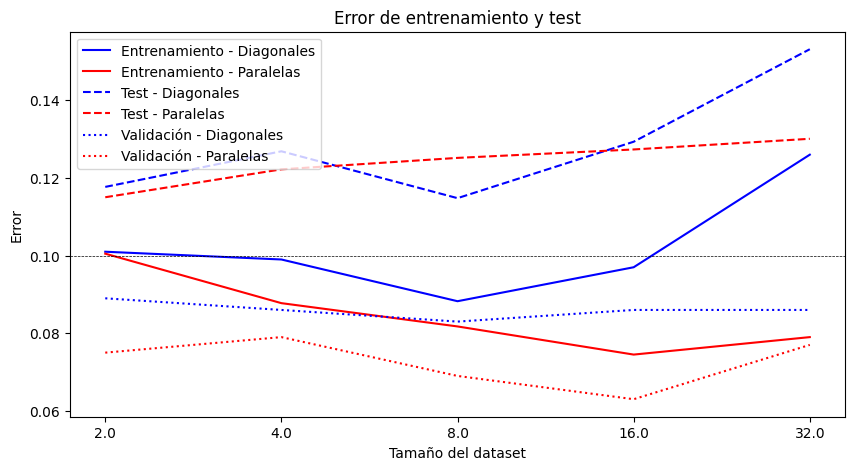

In [14]:
import matplotlib.ticker as mticker

labels = list(df_diagonales.columns)

fig, axs = plt.subplots(1, 1, figsize=(10, 5))

# ax[0] es la grafica del error y ax[1] es la grafica de los nodos

# Accedo a las columnas del dataframe
def getMean(df, col):
    return [np.mean(df[label][col]) for label in labels]

# Grafico de linea sizes vs train_error_mean, usar escala logaritmica en base 2 el eje x
# Muestro los numeros sin notacion cientifica
# Configurar el eje x para que no use notación científica
axs.set_xscale('log', base=2)
axs.plot(labels, getMean(df_diagonales, "train_error"), label='Entrenamiento - Diagonales', color='blue')
axs.plot(labels, getMean(df_paralelas,  "train_error"), label='Entrenamiento - Paralelas', color='red')
axs.plot(labels, getMean(df_diagonales, "test_error"), label='Test - Diagonales', color='blue', ls='--')
axs.plot(labels, getMean(df_paralelas, "test_error"), label='Test - Paralelas', color='red', ls='--')
axs.plot(labels, getMean(df_diagonales, "val_error"), label='Validación - Diagonales', color='blue', ls=':')
axs.plot(labels, getMean(df_paralelas, "val_error"), label='Validación - Paralelas', color='red', ls=':')
axs.set_title("Error de entrenamiento y test")
axs.set_xlabel("Tamaño del dataset")
axs.set_ylabel("Error")
axs.legend()
axs.xaxis.set_major_formatter(mticker.ScalarFormatter())

# Grafico una linea horizontal en y = 0.10
axs.axhline(y=0.10, color='black', lw=0.5, ls='--')


plt.plot()

## Ejercicio 6

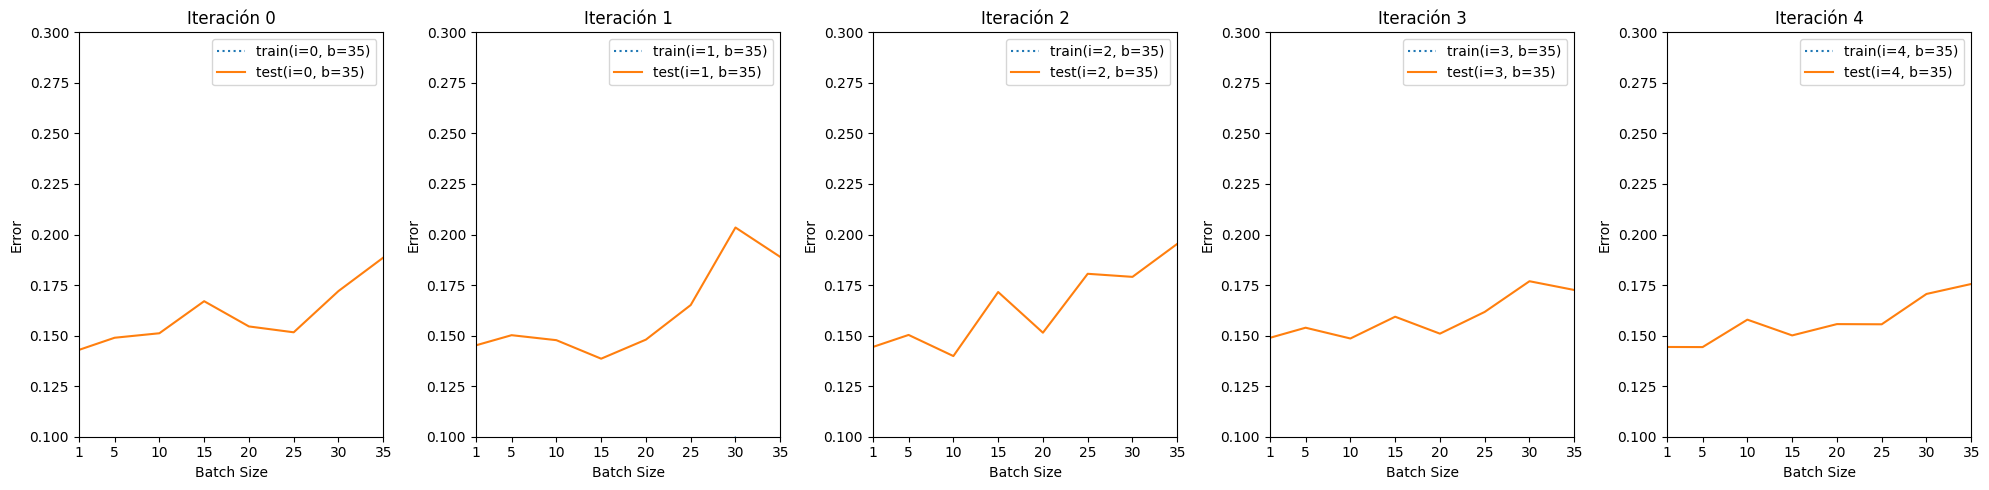

In [30]:
df = pd.read_csv("ssp.data", header=None)

eta = 0.05
alfa = 0.3
super_epocas = 2000
sub_epocas = 200
N2 = 6

# Ahora el regresor usa un batch size distinto
def Regresor(b):
   return MLPRegressor(hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', batch_size=b, learning_rate='constant', 
    learning_rate_init=eta,momentum=alfa,nesterovs_momentum=False,tol=0.0,warm_start=True,max_iter=sub_epocas)
    
bs = [1,5, 10, 15, 20, 25, 30, 35]

df_test = pd.read_csv("ssp.test", header=None)


X_data = df.iloc[:, :-1].values.tolist()
Y_data = df.iloc[:, -1].values.tolist()

X_train,X_val,Y_train,Y_val = skl.model_selection.train_test_split(X_data,Y_data, train_size=0.2)

X_test = df_test.iloc[:, :-1].values.tolist()
Y_test = df_test.iloc[:, -1].values.tolist()

ITERATIONS = 5

fig, ax = plt.subplots(1,ITERATIONS, figsize=(20, 5))

plt.title("Evolución del error vs Batch Size")

for i in range(ITERATIONS):
  total_train_error = []
  total_penalizacion = []
  total_test_error = []

  for b in bs:
    regr = Regresor(b)
    best_fit, train_error, penalizacion, test_error = entrenar_red(regr, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    total_train_error.append(1-best_fit.score(X_train, Y_train))
    total_test_error.append(1-best_fit.score(X_test, Y_test))

  ax[i].plot(bs, total_train_error, label="train(i={}, b={})".format(i,b), linestyle=":")
  ax[i].plot(bs, total_test_error, label="test(i={}, b={})".format(i,b), linestyle="-")
  ax[i].set_xticks(bs)  # Asegurar que los ticks del eje x son los batch sizes
  ax[i].set_xticklabels(bs)  # Asegurar que los ticks del eje x son los batch sizes
  ax[i].set_ylim(0.1, 0.3)  # Ajustar el límite del eje y para todas las gráficas
  ax[i].set_xlim(min(bs), max(bs))  # Ajustar el límite del eje x para todas las gráficas
  ax[i].set_xlabel("Batch Size")
  ax[i].set_ylabel("Error")
  ax[i].set_title("Iteración {}".format(i))
  ax[i].legend()

plt.tight_layout()
plt.show()



Para este ejercicio lo que se hizo fue seleccionar fue seleccionar los batches de longitud 1, 5, 10, 15, 20, 25, 30, 35 (el enunciado pide solamente 2 mas, pero seleccionamos mas para poder realizar un mejor análisis). 
Ademas de esto se decidió hace repetir el experimento una cierta cantidad de veces (en este caso 5 veces), ya que cada vez que repetíamos el experimento los resultados eran muy distintos; de esta forma se simplifica el análisis. La explicación de porque son tan distintos los valores a analizar se debe a que minibatch siempre empieza en un punto aleatorio de la superficie.

Lo primero que se puede observar es que el error del test es muy diferente en todas las iteraciones, pero el del train, a pesar de variar, tiene un comportamiento en común, a partir del 20 este aumenta.

* **¿Por que ocurre esto?** 
Una explicación puede ser que con valores pequeños del batch este tiende a parecerse al descenso de gradiente estocastico, volviéndose errático. Al ir aumentando el bacth se tiende a que se esquivar los mínimos.

* **¿Por que este el error crece mucho a partir del 20?** 
Esto se puede deber a que con valor de batch chicos el gradiente tiende a actualizarse mucho, pudiendo encontrar el mínimo mas fácilmente. Al aumentar el batch no se actualiza tanto tanto el gradiente por lo que no se llega a encontrar un mínimo de cualquier tipo.

* **¿Por que el error del test varia siempre a comparación del de train?**
La mejor explicación que le damos a este fenómeno es que el conjunto de test muy reducido en comparación al de train o validación.

## Ejercicio 7

In [22]:
X_data,Y_data = cargar_csv("faces.data", xcols=30*32)
display(X_data, Y_data)

# Lo mismo para el test
X_test,Y_test = cargar_csv("faces.test", xcols=30*32)
display(X_test, Y_test)

,0,1,2,3,4,5,6,7,8,9,...,950,951,952,953,954,955,956,957,958,959
0,5,19,24,23,23,21,20,19,19,18,...,121,121,121,121,120,119,119,104,41,37
1,23,32,31,31,30,29,28,26,25,24,...,122,127,106,91,100,95,127,126,51,2
2,3,8,41,36,36,34,33,32,30,29,...,89,81,88,90,85,79,86,63,58,2
3,23,21,20,18,17,16,14,13,12,10,...,111,111,111,105,111,110,110,88,25,26
4,0,1,53,19,2,23,48,25,6,17,...,24,23,18,14,21,19,19,16,14,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,3,7,38,34,33,32,31,30,28,28,...,85,83,81,83,79,72,79,59,50,1
256,35,34,33,32,29,28,26,24,23,21,...,50,61,84,119,91,63,70,96,49,0
257,44,41,39,37,35,33,31,29,28,24,...,10,9,10,7,5,5,9,10,9,42
258,28,26,24,23,21,19,18,17,15,13,...,118,118,118,118,118,116,116,89,28,29


0      1
1      2
2      2
3      0
4      3
      ..
255    1
256    1
257    1
258    2
259    0
Name: 960, Length: 260, dtype: int64

,0,1,2,3,4,5,6,7,8,9,...,950,951,952,953,954,955,956,957,958,959
0,41,39,36,34,32,30,29,27,25,21,...,7,7,5,3,6,3,3,2,2,35
1,52,48,45,41,38,35,32,29,26,7,...,37,37,23,35,29,26,36,23,19,0
2,33,32,30,29,27,25,23,21,20,19,...,30,22,17,45,45,44,43,40,35,32
3,9,34,21,17,56,41,50,49,45,44,...,52,92,79,89,103,88,58,56,13,2
4,35,34,32,31,28,26,25,24,22,20,...,21,22,21,76,70,50,48,44,49,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,34,32,31,29,27,25,24,22,21,19,...,17,19,37,52,38,44,44,43,39,34
360,41,39,37,35,33,31,29,28,26,22,...,7,7,7,5,5,2,5,13,47,44
361,32,58,50,50,46,44,43,41,39,37,...,1,1,6,33,14,8,5,10,1,0
362,14,33,32,31,30,28,27,25,23,22,...,129,126,128,122,126,127,126,119,49,0


0      3
1      2
2      0
3      3
4      1
      ..
359    2
360    3
361    3
362    2
363    3
Name: 960, Length: 364, dtype: int64

In [ ]:
N2 = 4
eta = 0.05
alfa = 0.3
super_epocas = 4000
sub_epocas = 20

In [ ]:
# El clasificador usa un batch size de 1
def Classifier():
    return MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

# Usamos la misma funcion de entrenamiento que antes

In [25]:
TRAINS = 1

# Normalizamos los datos al rango [0, 1]
X_data = X_data / 255.0
X_test = X_test / 255.0

display(X_data, Y_data)
display(X_test, Y_test)



,0,1,2,3,4,5,6,7,8,9,...,950,951,952,953,954,955,956,957,958,959
0,0.000077,0.000292,0.000369,0.000354,0.000354,0.000323,0.000308,0.000292,0.000292,0.000277,...,0.001861,0.001861,0.001861,0.001861,0.001845,0.001830,0.001830,0.001599,0.000631,0.000569
1,0.000354,0.000492,0.000477,0.000477,0.000461,0.000446,0.000431,0.000400,0.000384,0.000369,...,0.001876,0.001953,0.001630,0.001399,0.001538,0.001461,0.001953,0.001938,0.000784,0.000031
2,0.000046,0.000123,0.000631,0.000554,0.000554,0.000523,0.000507,0.000492,0.000461,0.000446,...,0.001369,0.001246,0.001353,0.001384,0.001307,0.001215,0.001323,0.000969,0.000892,0.000031
3,0.000354,0.000323,0.000308,0.000277,0.000261,0.000246,0.000215,0.000200,0.000185,0.000154,...,0.001707,0.001707,0.001707,0.001615,0.001707,0.001692,0.001692,0.001353,0.000384,0.000400
4,0.000000,0.000015,0.000815,0.000292,0.000031,0.000354,0.000738,0.000384,0.000092,0.000261,...,0.000369,0.000354,0.000277,0.000215,0.000323,0.000292,0.000292,0.000246,0.000215,0.000308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,0.000046,0.000108,0.000584,0.000523,0.000507,0.000492,0.000477,0.000461,0.000431,0.000431,...,0.001307,0.001276,0.001246,0.001276,0.001215,0.001107,0.001215,0.000907,0.000769,0.000015
256,0.000538,0.000523,0.000507,0.000492,0.000446,0.000431,0.000400,0.000369,0.000354,0.000323,...,0.000769,0.000938,0.001292,0.001830,0.001399,0.000969,0.001077,0.001476,0.000754,0.000000
257,0.000677,0.000631,0.000600,0.000569,0.000538,0.000507,0.000477,0.000446,0.000431,0.000369,...,0.000154,0.000138,0.000154,0.000108,0.000077,0.000077,0.000138,0.000154,0.000138,0.000646
258,0.000431,0.000400,0.000369,0.000354,0.000323,0.000292,0.000277,0.000261,0.000231,0.000200,...,0.001815,0.001815,0.001815,0.001815,0.001815,0.001784,0.001784,0.001369,0.000431,0.000446


0      1
1      2
2      2
3      0
4      3
      ..
255    1
256    1
257    1
258    2
259    0
Name: 960, Length: 260, dtype: int64

,0,1,2,3,4,5,6,7,8,9,...,950,951,952,953,954,955,956,957,958,959
0,0.000631,0.000600,0.000554,0.000523,0.000492,0.000461,0.000446,0.000415,0.000384,0.000323,...,0.000108,0.000108,0.000077,0.000046,0.000092,0.000046,0.000046,0.000031,0.000031,0.000538
1,0.000800,0.000738,0.000692,0.000631,0.000584,0.000538,0.000492,0.000446,0.000400,0.000108,...,0.000569,0.000569,0.000354,0.000538,0.000446,0.000400,0.000554,0.000354,0.000292,0.000000
2,0.000507,0.000492,0.000461,0.000446,0.000415,0.000384,0.000354,0.000323,0.000308,0.000292,...,0.000461,0.000338,0.000261,0.000692,0.000692,0.000677,0.000661,0.000615,0.000538,0.000492
3,0.000138,0.000523,0.000323,0.000261,0.000861,0.000631,0.000769,0.000754,0.000692,0.000677,...,0.000800,0.001415,0.001215,0.001369,0.001584,0.001353,0.000892,0.000861,0.000200,0.000031
4,0.000538,0.000523,0.000492,0.000477,0.000431,0.000400,0.000384,0.000369,0.000338,0.000308,...,0.000323,0.000338,0.000323,0.001169,0.001077,0.000769,0.000738,0.000677,0.000754,0.000738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,0.000523,0.000492,0.000477,0.000446,0.000415,0.000384,0.000369,0.000338,0.000323,0.000292,...,0.000261,0.000292,0.000569,0.000800,0.000584,0.000677,0.000677,0.000661,0.000600,0.000523
360,0.000631,0.000600,0.000569,0.000538,0.000507,0.000477,0.000446,0.000431,0.000400,0.000338,...,0.000108,0.000108,0.000108,0.000077,0.000077,0.000031,0.000077,0.000200,0.000723,0.000677
361,0.000492,0.000892,0.000769,0.000769,0.000707,0.000677,0.000661,0.000631,0.000600,0.000569,...,0.000015,0.000015,0.000092,0.000507,0.000215,0.000123,0.000077,0.000154,0.000015,0.000000
362,0.000215,0.000507,0.000492,0.000477,0.000461,0.000431,0.000415,0.000384,0.000354,0.000338,...,0.001984,0.001938,0.001968,0.001876,0.001938,0.001953,0.001938,0.001830,0.000754,0.000000


0      3
1      2
2      0
3      3
4      1
      ..
359    2
360    3
361    3
362    2
363    3
Name: 960, Length: 364, dtype: int64

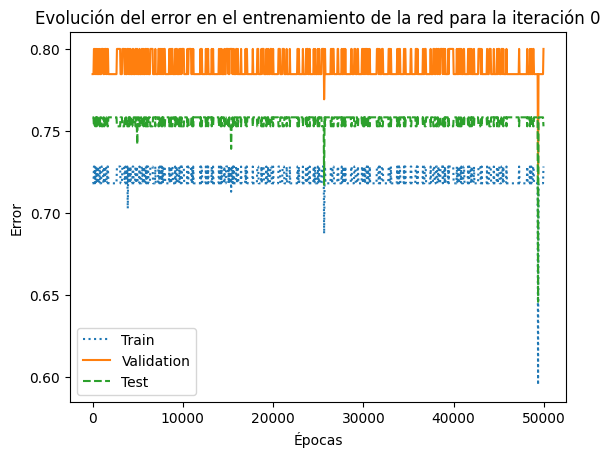

In [31]:
for i in range(TRAINS):
    # Un tercio para cada conjunto
    X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(X_data, Y_data, train_size=0.75)

    cla = Classifier()

    best_fit, train_error, val_error, test_error = entrenar_red(cla, X_train, Y_train, X_val, Y_val, X_test, Y_test)
    
    df[i] = {
        "train_error": train_error,
        "val_error": val_error,
        "test_error": test_error
    }

    rango = np.array(range(super_epocas)) * sub_epocas
    # Grafico las curvas de entrenamiento para cada iteración
    plt.plot(rango, train_error, label="Train".format(i), linestyle=":")
    plt.plot(rango, val_error, label="Validation".format(i), linestyle="-")
    plt.plot(rango, test_error, label="Test".format(i), linestyle="--")
    plt.title("Evolución del error en el entrenamiento de la red para la iteración {}".format(i))
    plt.xlabel("Épocas")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

df = pd.DataFrame.from_dict(df)
